                                  Logistic Regression _Heart Disease data

Task: Implement Logistic Regression ML model on heart disease data set and predict patient 
      has heart Disease or not.


In [ ]:
1.import libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
2. starts off importing heart diseases file and convrt into data Frame

In [5]:
df=pd.read_csv('heart_disease.xls')

In [6]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [ ]:
4.data preprocessing or EDA

In [7]:
#4.1 display the dimension
df.ndim

2

In [8]:
#4.2 display the totall sample of the data point
df.size

14350

In [9]:
# check the null values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
#4.4 display the each columns dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


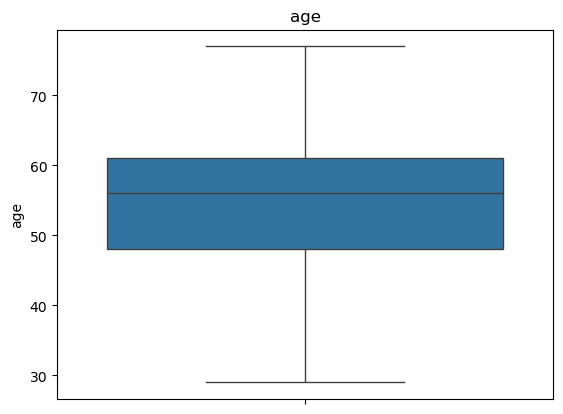

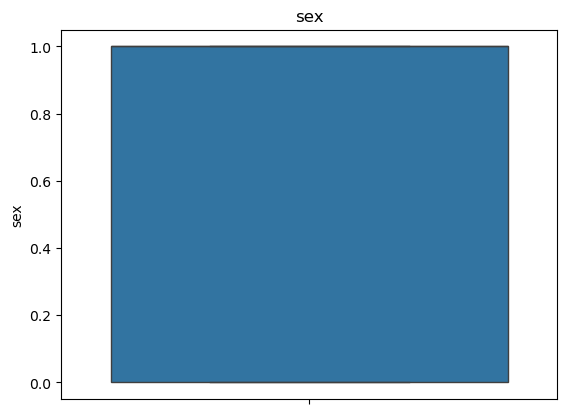

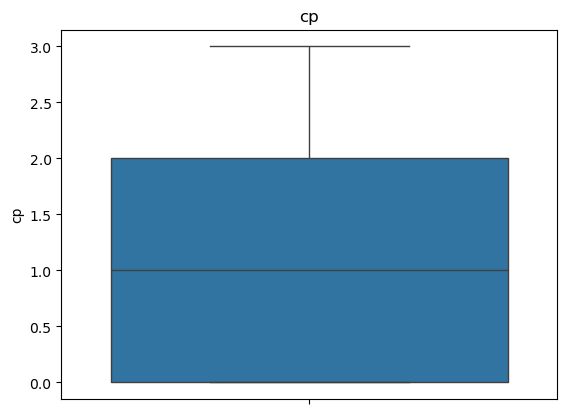

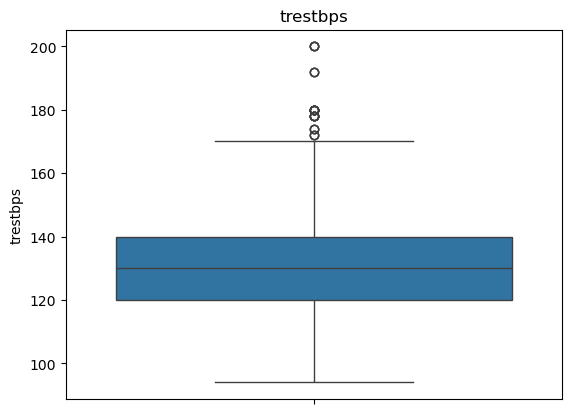

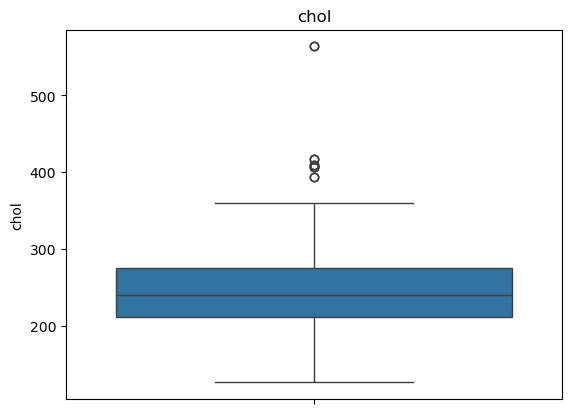

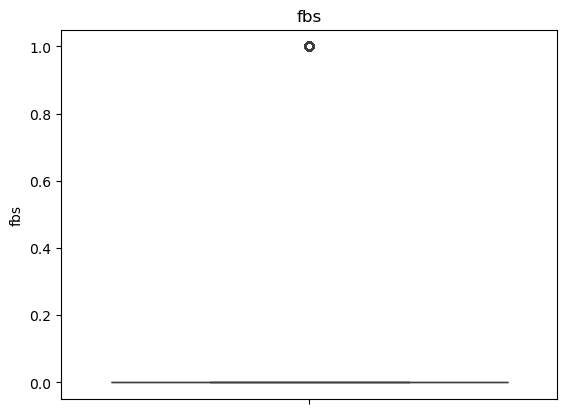

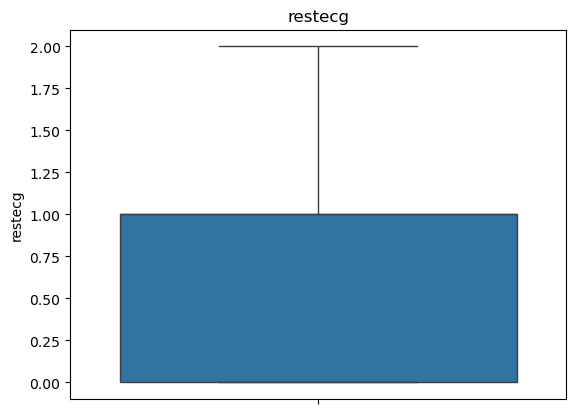

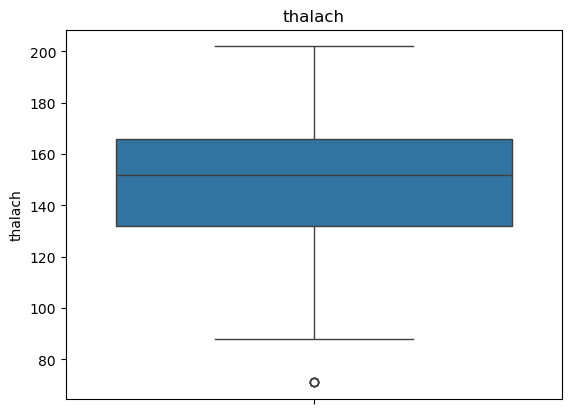

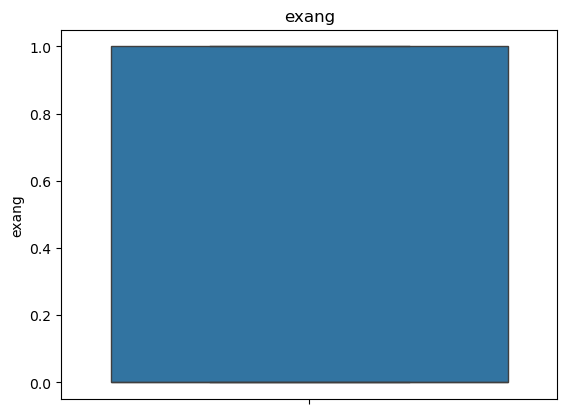

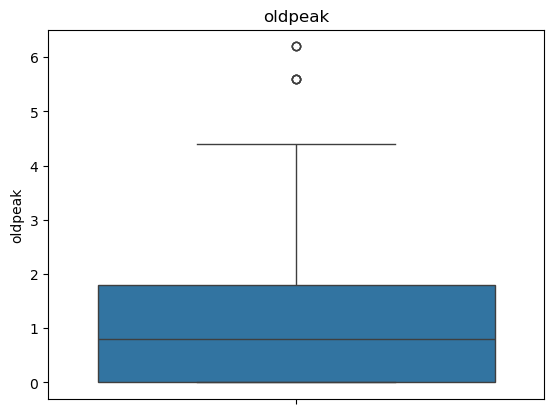

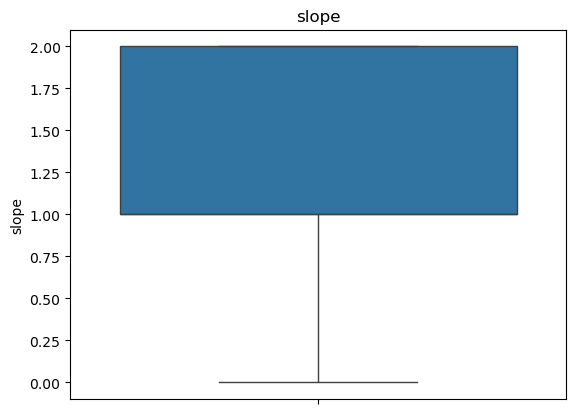

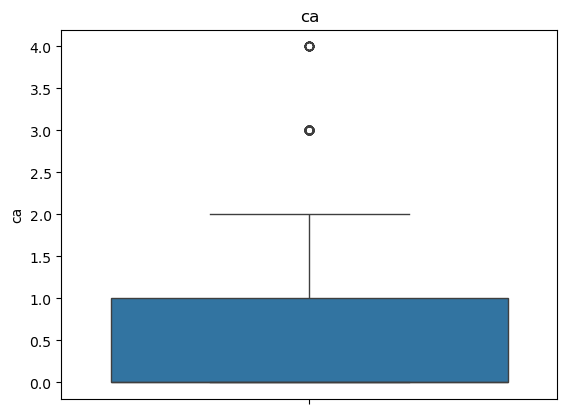

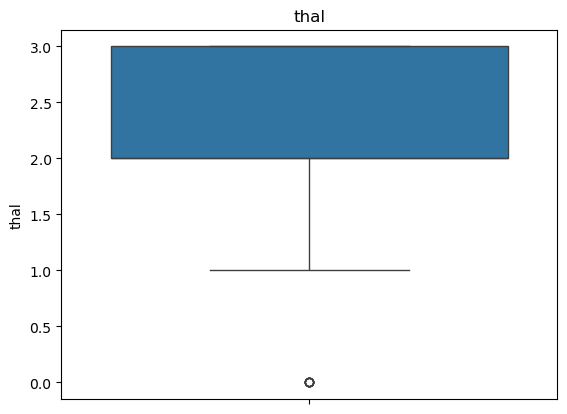

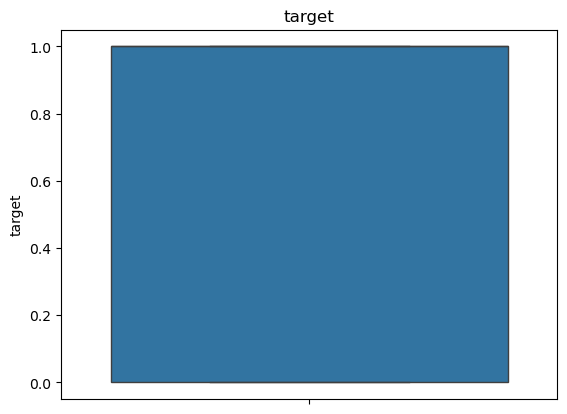

In [11]:
#4.5 check the outliers
for i in df.columns:
    if(df[i].dtype!='object'):
        sns.boxplot(df[i])
        plt.title(i)
        plt.show()

In [12]:
# remove the outlier 
out_cols=['trestbps','chol','oldpeak','ca']
for i in out_cols:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lb=q1-1.5*iqr
    ub=q3+1.5*iqr
    df=df[(df[i]>=lb) & (df[i]<=ub)]


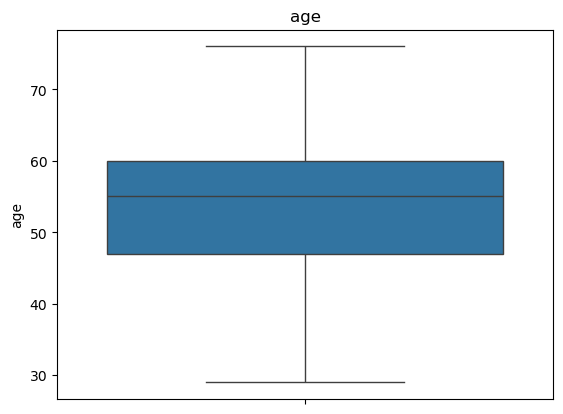

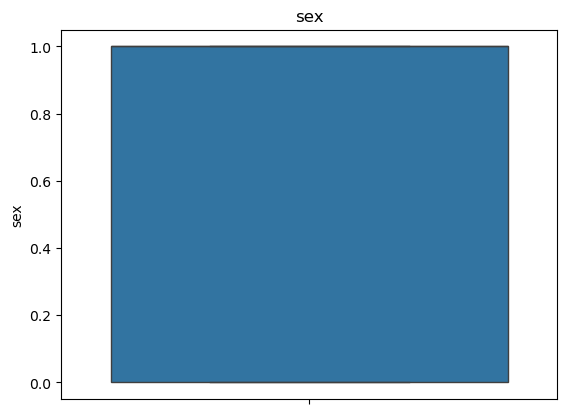

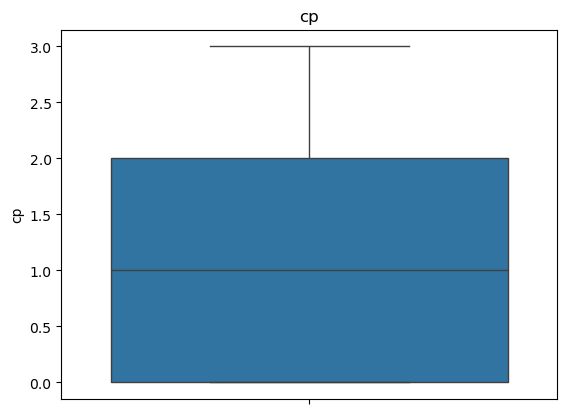

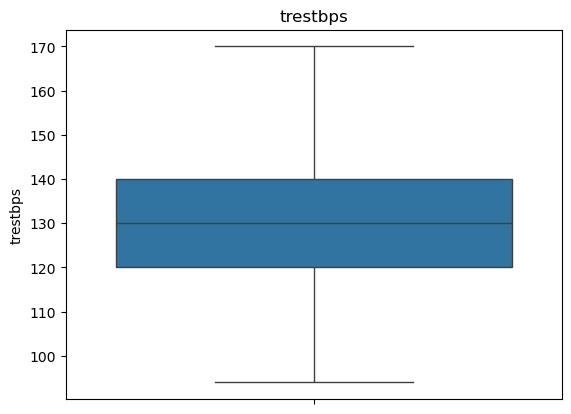

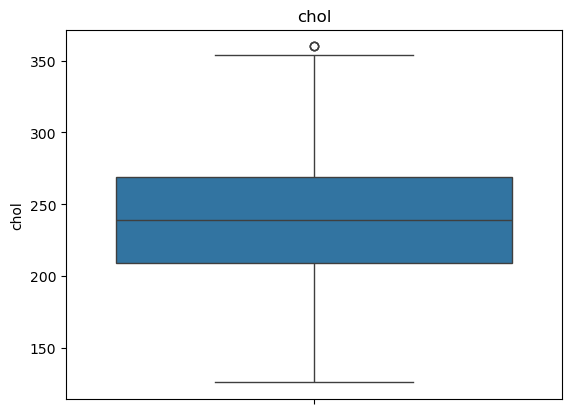

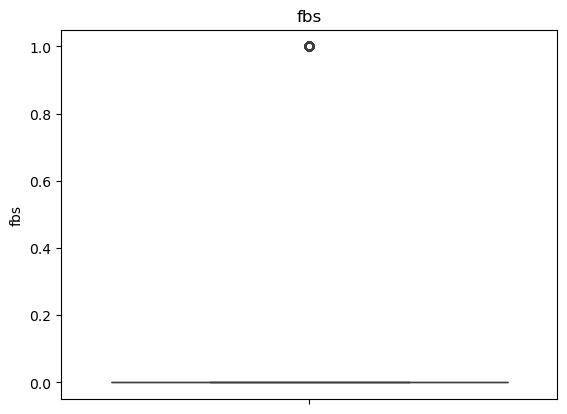

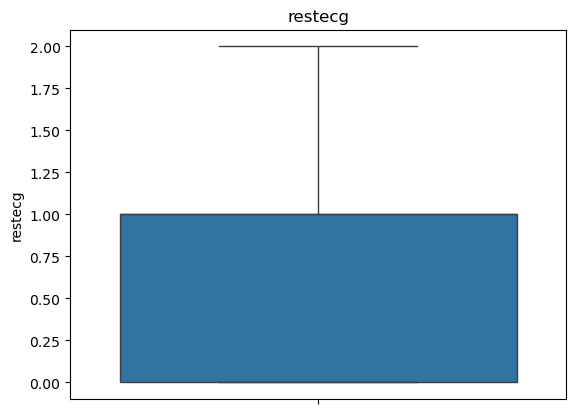

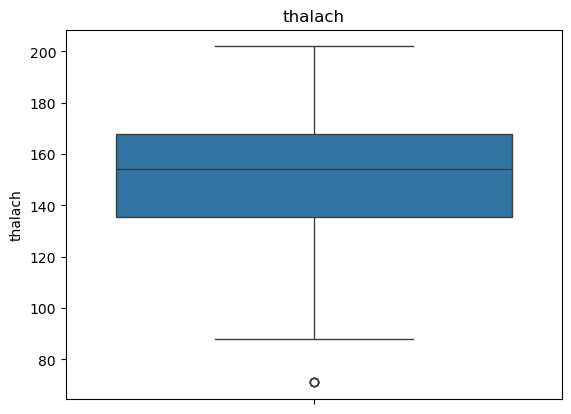

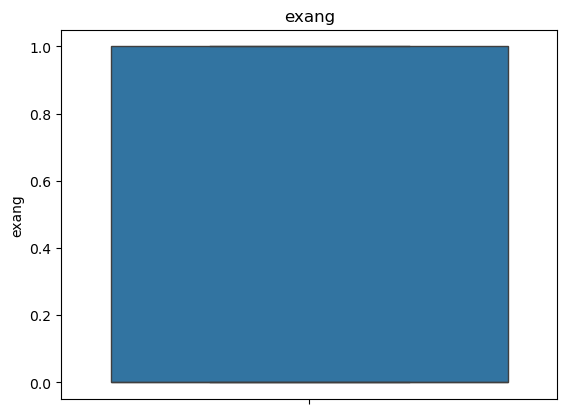

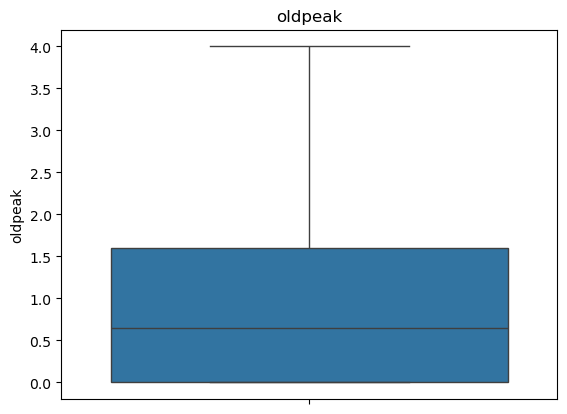

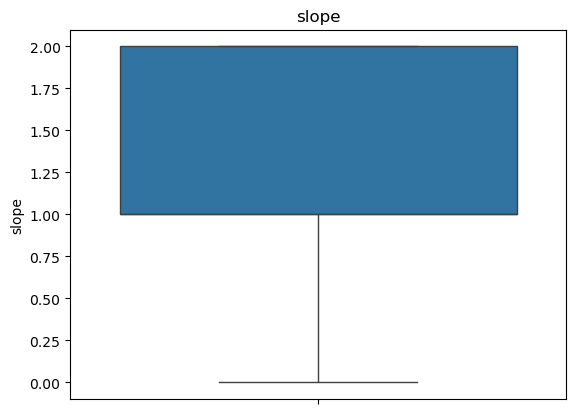

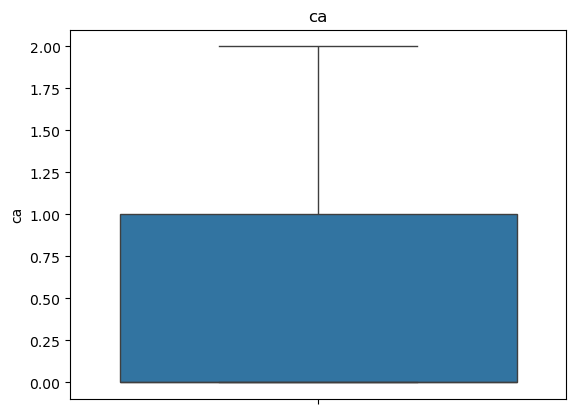

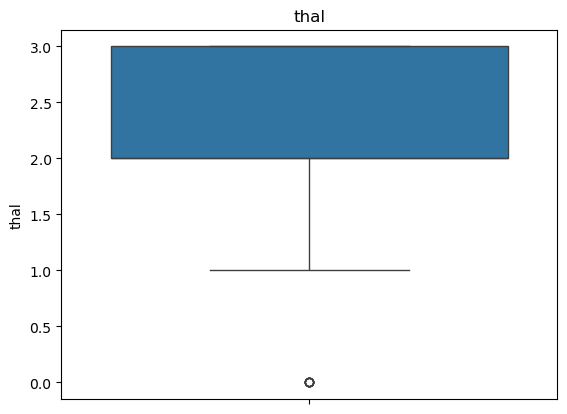

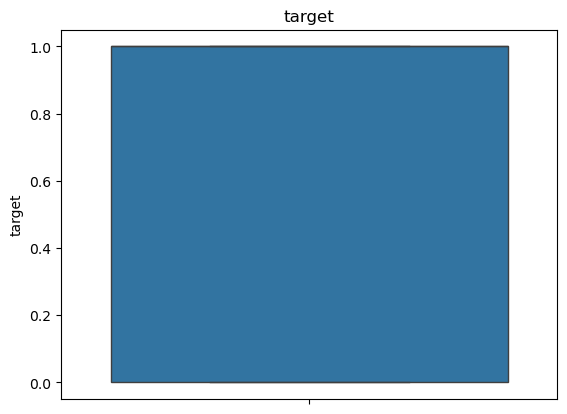

In [13]:
# again check the outlier
for i in df.columns:
    if df[i].dtype!='object':
        sns.boxplot(df[i])
        plt.title(i)
        plt.show()

In [ ]:
#4.9 split the data frame into indepent feature (x) and dependent feature(y)

In [14]:
x=df.drop('target',axis=1)
y=df['target']

In [ ]:
#4.12 split x and y into training data and testing data

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)
print('shape of x_train:',x_train.shape)
print('shape of x_test:',x_test.shape)
print('shape of y_train:',y_train.shape)
print('shape of y_test:',y_test.shape)

shape of x_train: (713, 13)
shape of x_test: (179, 13)
shape of y_train: (713,)
shape of y_test: (179,)


In [ ]:
#4.13 apply scalling on x_train and x_test data

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
5.Build ML Classification model(logistic Regression)

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
6.predict model output by applying testing data

In [19]:
y_pred=model.predict(x_test)

In [ ]:
7.display actual output ,model output and error terms

In [20]:
res=pd.DataFrame({'actual':y_test,
                  'predicted':y_pred,
                  'error':y_test-y_pred,
                  'error_square':(y_test-y_pred)**2})
res.head(10)

,actual,predicted,error,error_square
820,0,0,0,0
517,1,0,1,1
614,0,0,0,0
832,1,0,1,1
43,0,0,0,0
332,1,0,1,1
344,1,1,0,0
383,0,0,0,0
239,0,0,0,0
155,1,0,1,1


In [21]:
# display the numbers of error samples
res['error_square'].value_counts()

error_square
1    100
0     79
Name: count, dtype: int64

In [ ]:
#error sample =79
 normal sample=100

In [22]:
# Apply the fillter
res[res['error_square']==1].shape[0]

100

In [ ]:
8.performance evaluation

In [23]:
from sklearn.metrics import *

In [25]:
# 8.1 Display the confusion matrix
cm=confusion_matrix(y_test,y_pred)
print('Confusion matrix:\n',cm)

Confusion matrix:
 [[ 76   0]
 [100   3]]


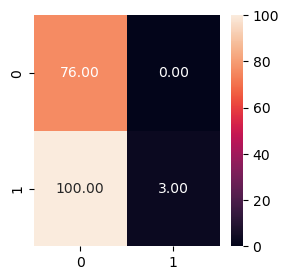

In [26]:
# 8.2 display the heat map
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True,fmt='0.2f')
plt.show()

In [27]:
#8.3 calculate pression 
print('precision:',precision_score(y_test,y_pred))

precision: 1.0


In [28]:
#8.4 Recall
print('Recall:',recall_score(y_test,y_pred))

Recall: 0.02912621359223301


In [29]:
#8.5 f1 score
print('f1 score:',f1_score(y_test,y_pred))

f1 score: 0.05660377358490566


In [30]:
#8.6 Accuracy
print('Accuracy:',accuracy_score(y_test,y_pred))

Accuracy: 0.441340782122905


In [31]:
#8.7 Classification Report
print('Classification Report:\n',classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.43      1.00      0.60        76
           1       1.00      0.03      0.06       103

    accuracy                           0.44       179
   macro avg       0.72      0.51      0.33       179
weighted avg       0.76      0.44      0.29       179

